# Demo: Toy CNN Activation Visualization

This notebook prototypes the exact interpretability tooling we will transfer to Baby U-Net.

## Objectives
- Train a small toy CNN quickly.
- Capture intermediate activations with forward hooks.
- Visualize channel behavior in a reproducible way.
- Export figures and notes for Person 1 integration.

## Required Notebook Outline
1. Set Up Environment and Dependencies
2. Define Project Configuration
3. Create Core Data Structures
4. Implement Main Processing Function
5. Add Input Validation and Error Handling
6. Write Unit Tests for Core Logic
7. Run Implementation and Inspect Output
8. Refactor into Reusable Modules

In [ ]:
# Section 1: Set Up Environment and Dependencies
import os
import random
import json
import math
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, TensorDataset

print(f"Python OK. Torch version: {torch.__version__}")

def set_seed(seed: int = 7) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Python OK. Torch version: 2.11.0+cu130
Device: cuda


In [ ]:
# Section 2: Define Project Configuration
@dataclass
class Config:
    seed: int = 7
    batch_size: int = 64
    lr: float = 1e-3
    epochs: int = 3
    train_subset_size: int = 5000
    val_subset_size: int = 1000
    output_dir: str = "./artifacts"
    sample_index: int = 0
    max_channels_to_plot: int = 8

cfg = Config()
set_seed(cfg.seed)
os.makedirs(cfg.output_dir, exist_ok=True)
print(asdict(cfg))

{'seed': 7, 'batch_size': 64, 'lr': 0.001, 'epochs': 3, 'train_subset_size': 5000, 'val_subset_size': 1000, 'output_dir': './artifacts', 'sample_index': 0, 'max_channels_to_plot': 8}


In [ ]:
# Section 3: Create Core Data Structures
@dataclass
class BatchInfo:
    images_shape: Tuple[int, ...]
    labels_shape: Tuple[int, ...]
    class_count: int

@dataclass
class EvalResult:
    accuracy: float
    loss: float

@dataclass
class ActivationRecord:
    layer_name: str
    tensor_shape: Tuple[int, ...]
    mean_abs_activation: float

class TinyCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.encoder_block1 = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.encoder_block2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.bottleneck = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.encoder_block1(x)
        x = self.encoder_block2(x)
        x = self.bottleneck(x)
        x = self.classifier(x)
        return x

print("TinyCNN defined.")

TinyCNN defined.


In [ ]:
# Section 4: Implement Main Processing Function

def load_toy_data(cfg: Config) -> Tuple[DataLoader, DataLoader, BatchInfo]:
    """Load MNIST (preferred) with sklearn digits fallback.

    Returns train/val loaders and metadata for sanity checks.
    """
    try:
        from torchvision import datasets, transforms

        transform = transforms.Compose([transforms.ToTensor()])
        train_ds_full = datasets.MNIST(root="./project/data", train=True, download=True, transform=transform)
        val_ds_full = datasets.MNIST(root="./project/data", train=False, download=True, transform=transform)

        train_idx = list(range(min(cfg.train_subset_size, len(train_ds_full))))
        val_idx = list(range(min(cfg.val_subset_size, len(val_ds_full))))

        train_ds = Subset(train_ds_full, train_idx)
        val_ds = Subset(val_ds_full, val_idx)

        train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)
    except Exception as exc:
        print(f"torchvision path failed, using sklearn digits fallback: {exc}")
        from sklearn.datasets import load_digits
        from sklearn.model_selection import train_test_split

        digits = load_digits()
        X = digits.images.astype(np.float32) / 16.0
        y = digits.target.astype(np.int64)
        X = np.pad(X, ((0, 0), (10, 10), (10, 10)), mode="constant")
        X = X[:, None, :, :]

        X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=cfg.seed, stratify=y)

        train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
        val_ds = TensorDataset(torch.from_numpy(X_va), torch.from_numpy(y_va))

        train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)

    sample_x, sample_y = next(iter(train_loader))
    meta = BatchInfo(
        images_shape=tuple(sample_x.shape),
        labels_shape=tuple(sample_y.shape),
        class_count=int(sample_y.max().item()) + 1,
    )
    return train_loader, val_loader, meta


def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer, criterion, device: torch.device) -> float:
    model.train()
    running = 0.0
    seen = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running += loss.item() * xb.size(0)
        seen += xb.size(0)
    return running / max(seen, 1)


def evaluate_model(model: nn.Module, loader: DataLoader, criterion, device: torch.device) -> EvalResult:
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += xb.size(0)
    return EvalResult(accuracy=correct / max(total, 1), loss=total_loss / max(total, 1))


train_loader, val_loader, meta = load_toy_data(cfg)
print(meta)

model = TinyCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
for epoch in range(cfg.epochs):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_result = evaluate_model(model, val_loader, criterion, device)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_result.loss)
    history["val_acc"].append(val_result.accuracy)
    print(f"Epoch {epoch+1}/{cfg.epochs} | train_loss={tr_loss:.4f} | val_loss={val_result.loss:.4f} | val_acc={val_result.accuracy:.4f}")

torchvision path failed, using sklearn digits fallback: No module named 'torchvision'
BatchInfo(images_shape=(64, 1, 28, 28), labels_shape=(64,), class_count=10)
Epoch 1/3 | train_loss=2.2988 | val_loss=2.2841 | val_acc=0.1917
Epoch 2/3 | train_loss=2.2468 | val_loss=2.1558 | val_acc=0.4667
Epoch 3/3 | train_loss=1.9353 | val_loss=1.6381 | val_acc=0.5139


In [ ]:
# Section 5: Add Input Validation and Error Handling

def validate_batch(x: torch.Tensor, y: torch.Tensor) -> None:
    if x.ndim != 4:
        raise ValueError(f"Expected image batch shape (N,C,H,W), got {tuple(x.shape)}")
    if y.ndim != 1:
        raise ValueError(f"Expected labels shape (N,), got {tuple(y.shape)}")
    if x.size(0) != y.size(0):
        raise ValueError("Mismatched batch dimension between inputs and labels")
    if x.size(1) != 1:
        raise ValueError("Toy CNN expects 1-channel grayscale images")

# Safe validation example
xb, yb = next(iter(train_loader))
validate_batch(xb, yb)
print("Validation passed for sample training batch.")

# Expected failure demos
try:
    validate_batch(xb.squeeze(1), yb)
except ValueError as e:
    print("Expected error 1:", e)

try:
    validate_batch(xb, yb.unsqueeze(1))
except ValueError as e:
    print("Expected error 2:", e)

Validation passed for sample training batch.
Expected error 1: Expected image batch shape (N,C,H,W), got (64, 28, 28)
Expected error 2: Expected labels shape (N,), got (64, 1)


In [ ]:
# Section 6: Write Unit Tests for Core Logic
import unittest

class TestCoreLogic(unittest.TestCase):
    def test_tinycnn_output_shape(self):
        m = TinyCNN(num_classes=10)
        out = m(torch.randn(4, 1, 28, 28))
        self.assertEqual(tuple(out.shape), (4, 10))

    def test_validate_batch_ok(self):
        x = torch.randn(2, 1, 28, 28)
        y = torch.tensor([1, 2])
        validate_batch(x, y)

    def test_validate_batch_bad_dims(self):
        x = torch.randn(2, 28, 28)
        y = torch.tensor([1, 2])
        with self.assertRaises(ValueError):
            validate_batch(x, y)

suite = unittest.defaultTestLoader.loadTestsFromTestCase(TestCoreLogic)
result = unittest.TextTestRunner(verbosity=2).run(suite)
print(f"Tests run: {result.testsRun}, failures: {len(result.failures)}, errors: {len(result.errors)}")

test_tinycnn_output_shape (__main__.TestCoreLogic) ... ok
test_validate_batch_bad_dims (__main__.TestCoreLogic) ... ok
test_validate_batch_ok (__main__.TestCoreLogic) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.116s

OK


Tests run: 3, failures: 0, errors: 0


In [ ]:
# Section 7: Run Implementation and Inspect Output

class ActivationCatcher:
    def __init__(self, model: nn.Module, layer_names: List[str]):
        self.model = model
        self.layer_names = layer_names
        self.activations: Dict[str, torch.Tensor] = {}
        self.handles = []

    def _hook(self, name: str):
        def fn(module, inp, out):
            self.activations[name] = out.detach().cpu()
        return fn

    def register(self):
        module_dict = dict(self.model.named_modules())
        for name in self.layer_names:
            if name not in module_dict:
                raise KeyError(f"Layer '{name}' not found in model.")
            self.handles.append(module_dict[name].register_forward_hook(self._hook(name)))

    def clear(self):
        self.activations.clear()

    def remove(self):
        for h in self.handles:
            h.remove()
        self.handles = []


def get_single_sample(loader: DataLoader, index: int = 0) -> Tuple[torch.Tensor, int]:
    all_x = []
    all_y = []
    for xb, yb in loader:
        all_x.append(xb)
        all_y.append(yb)
    X = torch.cat(all_x, dim=0)
    Y = torch.cat(all_y, dim=0)
    idx = min(index, X.size(0) - 1)
    return X[idx:idx+1], int(Y[idx].item())

layer_names = ["encoder_block1.0", "encoder_block2.0", "bottleneck.0"]
catcher = ActivationCatcher(model, layer_names)
catcher.register()

x_sample, y_true = get_single_sample(val_loader, cfg.sample_index)
with torch.no_grad():
    logits = model(x_sample.to(device))
    y_pred = int(logits.argmax(dim=1).item())

records = []
for ln, act in catcher.activations.items():
    records.append(ActivationRecord(
        layer_name=ln,
        tensor_shape=tuple(act.shape),
        mean_abs_activation=float(act.abs().mean().item()),
    ))

print(f"True label: {y_true}, Pred label: {y_pred}")
for r in records:
    print(r)

catcher.remove()

True label: 9, Pred label: 1
ActivationRecord(layer_name='encoder_block1.0', tensor_shape=(1, 8, 28, 28), mean_abs_activation=0.12458114326000214)
ActivationRecord(layer_name='encoder_block2.0', tensor_shape=(1, 16, 14, 14), mean_abs_activation=0.17693117260932922)
ActivationRecord(layer_name='bottleneck.0', tensor_shape=(1, 16, 7, 7), mean_abs_activation=0.38191020488739014)


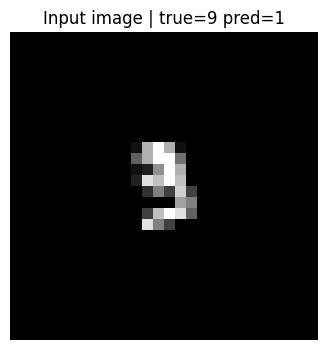

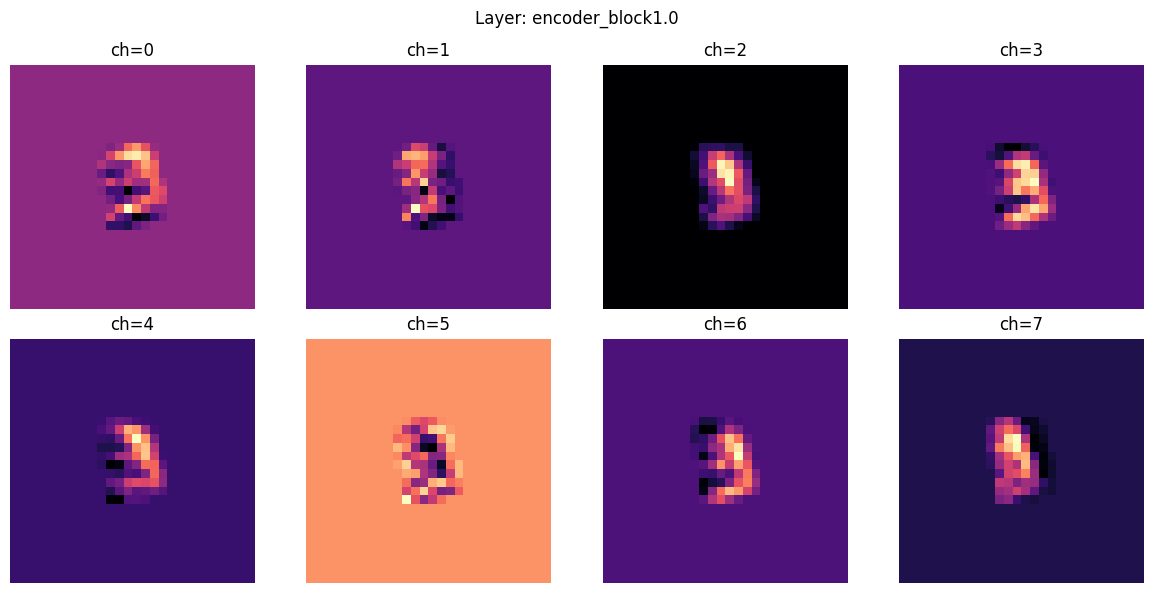

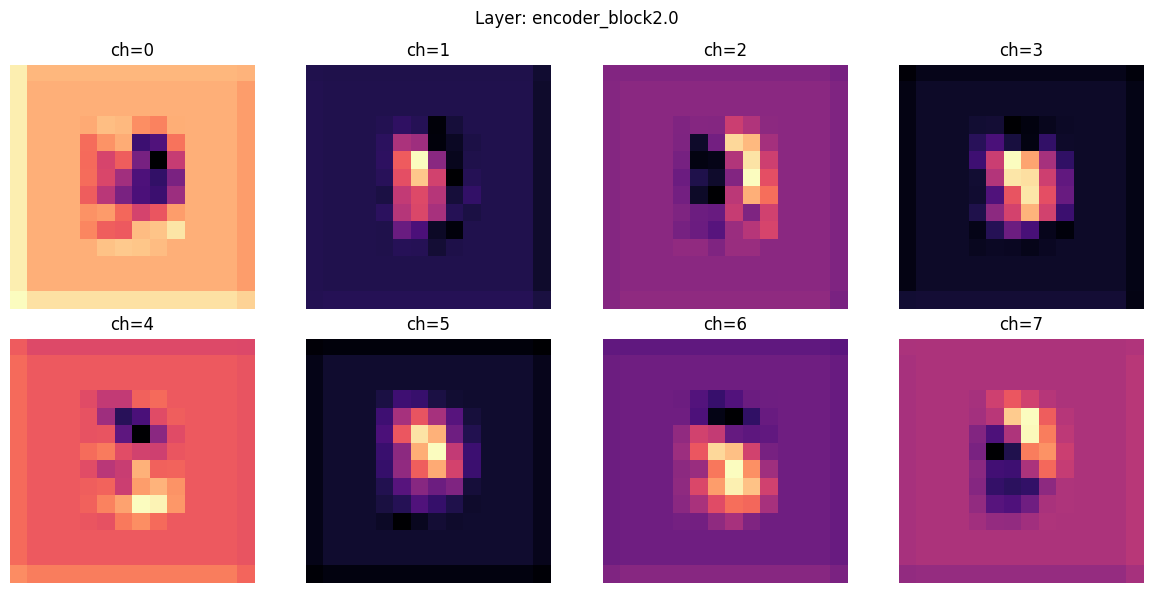

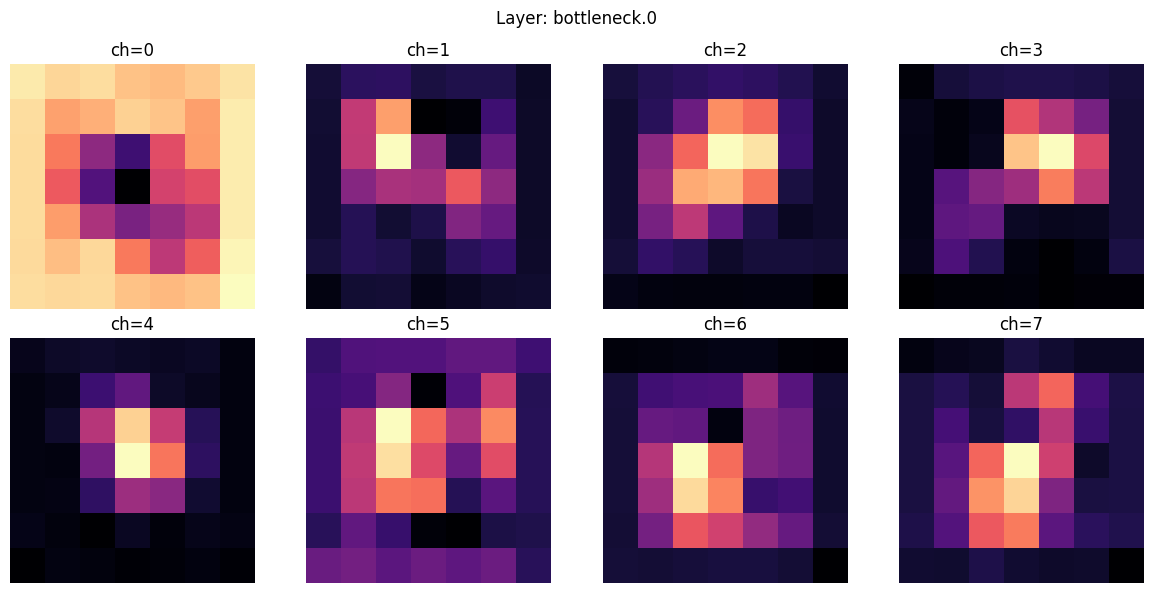

Artifacts written to: ./artifacts
Summary JSON: ./artifacts/prototype_summary.json


In [ ]:
# Section 8: Refactor into Reusable Modules (utilities + exports)

def normalize_map(arr: np.ndarray) -> np.ndarray:
    arr = arr.astype(np.float32)
    min_v, max_v = arr.min(), arr.max()
    if max_v - min_v < 1e-8:
        return np.zeros_like(arr)
    return (arr - min_v) / (max_v - min_v)


def plot_activation_grid(activation: torch.Tensor, title: str, max_channels: int = 8, save_path: Optional[str] = None):
    # activation shape: (1, C, H, W)
    act = activation[0].numpy()
    c = min(max_channels, act.shape[0])
    cols = 4
    rows = int(math.ceil(c / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        ax.axis("off")
        if i < c:
            ax.imshow(normalize_map(act[i]), cmap="magma")
            ax.set_title(f"ch={i}")

    fig.suptitle(title)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def run_activation_demo(model: nn.Module, x: torch.Tensor, layer_names: List[str], output_dir: str, max_channels: int = 8):
    catcher = ActivationCatcher(model, layer_names)
    catcher.register()
    with torch.no_grad():
        _ = model(x.to(device))

    summary = {}
    for ln, act in catcher.activations.items():
        save_path = os.path.join(output_dir, f"activation_{ln.replace('.', '_')}.png")
        plot_activation_grid(act, title=f"Layer: {ln}", max_channels=max_channels, save_path=save_path)
        summary[ln] = {
            "shape": list(act.shape),
            "mean_abs": float(act.abs().mean().item()),
            "saved_figure": save_path,
        }

    catcher.remove()
    return summary

# Run end-to-end export
x_sample, y_true = get_single_sample(val_loader, cfg.sample_index)
with torch.no_grad():
    logits = model(x_sample.to(device))
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    y_pred = int(np.argmax(probs))

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(x_sample[0, 0].numpy(), cmap="gray")
ax.set_title(f"Input image | true={y_true} pred={y_pred}")
ax.axis("off")
input_fig_path = os.path.join(cfg.output_dir, "input_prediction.png")
fig.savefig(input_fig_path, dpi=150, bbox_inches="tight")
plt.show()

summary = run_activation_demo(
    model=model,
    x=x_sample,
    layer_names=["encoder_block1.0", "encoder_block2.0", "bottleneck.0"],
    output_dir=cfg.output_dir,
    max_channels=cfg.max_channels_to_plot,
)

project_summary = {
    "owner": "Raghav",
    "teammates": {
        "person_1": "Pranav",
        "person_3": "Tiehang Zhang"
    },
    "prototype": "Toy CNN activation visualization",
    "model_prediction": {
        "true_label": y_true,
        "pred_label": y_pred,
        "top_prob": float(probs[y_pred]),
    },
    "artifacts": {
        "input_prediction": input_fig_path,
        "layer_activations": summary,
    },
    "integration_notes": {
        "replace_model": "TinyCNN -> Baby U-Net",
        "hook_targets": ["encoder_block1", "encoder_block2", "bottleneck"],
        "reusable_components": [
            "ActivationCatcher class",
            "plot_activation_grid function",
            "artifact export flow"
        ]
    }
}

json_path = os.path.join(cfg.output_dir, "prototype_summary.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(project_summary, f, indent=2)

print(f"Artifacts written to: {cfg.output_dir}")
print(f"Summary JSON: {json_path}")

## Integration Notes (Natural Version)

### What is already complete in this notebook
- Forward hooks capture hidden activations by layer name.
- Per-channel activation maps are visualized and exported.
- A compact JSON summary is generated with outputs and layer stats.

### How to adapt to Baby U-Net
- Swap TinyCNN for the trained Baby U-Net model.
- Update the layer list to real U-Net module names.
- Run one forward pass on an X-ray image tensor.
- Reuse the same plotting and export functions.

### Suggested layer targets in U-Net
- First encoder conv block.
- Deeper encoder conv block.
- Bottleneck conv block.

### Why this prototype is useful
- It confirms the interpretability pipeline works end-to-end.
- It keeps the code modular for fast model swaps.
- It gives ready visual assets for project communication.

## Video Script (Pranav presenting, Raghav segment)

Title: Unpacking the U-Net Bottleneck: Phase-2 Team Progress

In this section, I will briefly present Raghav's contribution, which is Person 2 Task 1: prototyping activation-visualization tooling on a toy CNN while we wait for the trained Baby U-Net checkpoint.

Raghav's goal was to validate the interpretability pipeline itself. The prototype trains a small CNN, attaches forward hooks to selected internal layers, captures activation tensors, and visualizes per-channel activation maps from early encoder layers and the bottleneck.

The key result is that the tooling works end-to-end: we can consistently extract, visualize, and export layer activations with reusable code. This gives us a stable foundation for the next phase, where the same workflow is applied to Baby U-Net by updating model and layer names.

From the observed maps, earlier layers respond to local edge-like patterns, while deeper layers show more abstract, compact feature responses. That behavior is exactly what we expected and is useful for later channel-level analysis.

This concludes Raghav's segment. In the next sections, I will cover my Person 1 Task 1 progress and then Tiehang's Person 3 Task 1 progress, so the full team pipeline is connected from model setup to interpretability and ablation planning.